In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
from tqdm import tqdm, trange

sys.path.append("../../")
import biked_commons
from biked_commons.design_evaluation.design_evaluation import *
from biked_commons.resource_utils import split_datasets_path
from biked_commons.conditioning import conditioning
from biked_commons.design_evaluation.scoring import *
from biked_commons.benchmark_models import generative_modeling_utils, benchmarking_utils


In [2]:
import importlib
importlib.reload(generative_modeling_utils)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data = pd.read_csv(split_datasets_path("bike_bench.csv"), index_col=0)
data_tens = torch.tensor(data.values, dtype=torch.float32, device=device)

scaler = generative_modeling_utils.TorchScaler(data_tens)

scaled_data_tens = scaler.scale(data_tens)

continuous_conditioning = generative_modeling_utils.sample_continuous(len(scaled_data_tens))
aux_fn = generative_modeling_utils.get_diversity_loss_fn(scaler, 100, 0.1, 100, 10, device=device)

In [ ]:
# train_params = batch_size, disc_lr, gen_lr, noise_dim, num_epochs, n_hidden, layer_size
noise_dim = 10
batch_size = 256
train_params = (batch_size, 0.001, 0.001, noise_dim, 5, 2, 256)
D, G, generate_fn = generative_modeling_utils.train_model(scaled_data_tens, "GAN", train_params, aux_fn, device)


c:\Users\Lyle\Documents\Files\DeCoDE\biked-commons\src\biked_commons\benchmark_models\../..\biked_commons\benchmark_models\generative_modeling_utils.py:443: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data).float()
  0%|          | 0/87 [00:00<?, ?it/s]c:\Users\Lyle\Documents\Files\DeCoDE\biked-commons\src\biked_commons\benchmark_models\../..\biked_commons\benchmark_models\generative_modeling_utils.py:88: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3281.)
  Q = torch.matmul(scores

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ C:\Users\Lyle\AppData\Local\Temp\ipykernel_33756\3136072840.py:5 in <module>                     │
│                                                                                                  │
│ [Errno 2] No such file or directory:                                                             │
│ 'C:\\Users\\Lyle\\AppData\\Local\\Temp\\ipykernel_33756\\3136072840.py'                          │
│                                                                                                  │
│ c:\Users\Lyle\Documents\Files\DeCoDE\biked-commons\src\biked_commons\benchmark_models\../..\bike │
│ d_commons\benchmark_models\generative_modeling_utils.py:503 in train_model                       │
│                                                                                                  │
│   500 │   │   num_steps = -num_epochs #hacky way to specify fixed number of steps rather than    │
│   501 │                                                                                          │
│   502 │                                                                                          │
│ ❱ 503 │   train(D, G, D_opt, G_opt, loader, num_steps, batch_size, noise_dim, train_step, devi   │
│   504 │                                                                                          │
│   505 │   return D, G, generate_fn                                                               │
│   506                                                                                            │
│                                                                                                  │
│ c:\Users\Lyle\Documents\Files\DeCoDE\biked-commons\src\biked_commons\benchmark_models\../..\bike │
│ d_commons\benchmark_models\generative_modeling_utils.py:333 in train                             │
│                                                                                                  │
│   330 │   for step in steps_range:                                                               │
│   331 │   │   data_batch = loader.get_batch().to(device)                                         │
│   332 │   │   noise_batch = torch.randn(batch_size, noise_dim).to(device)                        │
│ ❱ 333 │   │   cond_batch = sample_continuous(batch_size, split="train", randomize=True).to(dev   │
│   334 │   │                                                                                      │
│   335 │   │   report = train_step_fn(D, G, D_opt, G_opt, data_batch, cond_batch, noise_batch,    │
│   336 │   │   postfix = {key: "{:.4f}".format(value) for key, value in report.items()}           │
│                                                                                                  │
│ c:\Users\Lyle\Documents\Files\DeCoDE\biked-commons\src\biked_commons\benchmark_models\../..\bike │
│ d_commons\benchmark_models\generative_modeling_utils.py:28 in sample_continuous                  │
│                                                                                                  │
│    25                                                                                            │
│    26 def sample_continuous(num_samples, split="test", randomize = False):                       │
│    27 │   emb = conditioning.sample_image_embedding(num_samples, split, randomize)               │
│ ❱  28 │   rider = conditioning.sample_riders(num_samples, split, randomize)                      │
│    29 │   use_case = conditioning.sample_use_case(num_samples, split, randomize)                 │
│    30 │   all = torch.cat((emb, rider, use_case), dim=1)                                         │
│    31 │   return all                                                                             │
│                                                                                                  │
│ c:\Users\Lyle\Documents\Files\DeCoDE\biked-commons\src\bike

In [ ]:
def predict(cond_test):
    cond_test = cond_test.to(device)
    predictions = []
    #use batch size
    for i in range(0, len(cond_test), batch_size):
        batch = cond_test[i:i + batch_size]
        with torch.no_grad():
            pred = generate_fn(D, G, batch, noise_dim, device=device)
            pred = scaler.unscale(pred)
            predictions.append(pred)
    predictions = torch.concat(predictions, axis=0)
    return predictions


In [ ]:
continuous_condition = generative_modeling_utils.sample_continuous(10000, split="test", randomize=False)
condition = generative_modeling_utils.parse_continuous_condition(continuous_condition)
predictions = predict(continuous_condition).detach()

main_scores, detailed_scores = benchmarking_utils.evaluate_cond(predictions, "GAN-PA", data.columns, device=device)

print("Main scores: ", main_scores)
print("Detailed scores: ", detailed_scores)


Main scores:  Hypervolume                     0.000000
Constraint Satisfaction Rate    0.000000
Maximum Mean Discrepancy        1.197043
dtype: float64
Detailed scores:  Min Objective Score: Usability Score - 0 to 1                                                                 1.000000
Min Objective Score: Drag Force                                                                              29.636734
Min Objective Score: Knee Angle Error                                                                       197.293720
Min Objective Score: Hip Angle Error                                                                        807.759030
Min Objective Score: Arm Angle Error                                                                        843.490000
Min Objective Score: Cosine Distance to Embedding                                                             0.054179
Min Objective Score: Mass                                                                                    29.1030

In [ ]:
#get counts of negative values in each column of the predictions

def count_negatives(predictions):
    counts = {}
    for i in range(predictions.shape[1]):
        counts[i] = (predictions[:, i] < 0).sum().item()
    return counts

print("Counts of negative values in each column: ", count_negatives(predictions))



Counts of negative values in each column:  {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 9999, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0, 28: 0, 29: 0, 30: 10000, 31: 10000, 32: 0, 33: 10000, 34: 0, 35: 0, 36: 0, 37: 0, 38: 0, 39: 0, 40: 0, 41: 0, 42: 0, 43: 10000, 44: 10000, 45: 10000, 46: 10000, 47: 0, 48: 10000, 49: 0, 50: 10000, 51: 0, 52: 10000, 53: 0, 54: 0, 55: 0, 56: 0, 57: 0, 58: 0, 59: 0, 60: 0, 61: 0, 62: 0, 63: 0, 64: 0, 65: 10000, 66: 0, 67: 0, 68: 0, 69: 0, 70: 0, 71: 10000, 72: 0, 73: 0, 74: 10000, 75: 0, 76: 10000, 77: 0, 78: 0, 79: 0, 80: 0, 81: 10000, 82: 0, 83: 0, 84: 0, 85: 0, 86: 10000, 87: 0, 88: 10000, 89: 0, 90: 0, 91: 0, 92: 0, 93: 10000}


In [ ]:
import importlib
importlib.reload(generative_modeling_utils)
composite_score_fn = generative_modeling_utils.get_composite_score_fn(constrant_vs_objective_weight=100, device=device)


In [ ]:
predictions.requires_grad = True
cs = composite_score_fn(predictions, continuous_condition)
loss = cs.sum()
loss.backward()

In [ ]:
data.columns[76]

'RIM_STYLE front OHCLASS: DISC'

In [ ]:
predictions.grad[:, 0]

tensor([3.0630e-07, 3.4508e-07, 3.4536e-07,  ..., 3.3364e-07, 3.4723e-07,
        2.8912e-07], device='cuda:0')

In [ ]:
prediction_step = predictions -  predictions.grad*10000

In [ ]:
predictions

tensor([[430.2375, 117.0515, 445.9666,  ...,   0.4873,   2.4981,  -1.4724],
        [432.1345, 113.5048, 448.0464,  ...,   0.4585,   2.4471,  -1.4057],
        [431.5588, 114.3107, 447.2516,  ...,   0.4675,   2.4604,  -1.4147],
        ...,
        [432.8282, 113.6586, 446.2606,  ...,   0.4614,   2.4432,  -1.4038],
        [431.6768, 113.8864, 447.4406,  ...,   0.4566,   2.4456,  -1.3919],
        [430.8414, 117.2459, 441.7856,  ...,   0.4849,   2.5351,  -1.5005]],
       device='cuda:0', requires_grad=True)

In [ ]:
score_step = composite_score_fn(prediction_step, continuous_condition)

In [ ]:
cs- score_step

tensor([nan, nan, nan,  ..., nan, nan, nan], device='cuda:0',
       grad_fn=<SubBackward0>)

In [ ]:
ccd = generative_modeling_utils.sample_continuous(len(data_tens), split="test", randomize=False)
composite_score_fn(data_tens, ccd)

tensor([0.0003, 0.0004, 0.0005,  ..., 0.0001, 0.0004, 0.0007], device='cuda:0',
       grad_fn=<DivBackward0>)

In [ ]:
evaluator, requirement_names, requirement_types = construct_tensor_evaluator(get_standard_evaluations(device), data.columns)

In [ ]:
from biked_commons.design_evaluation import scoring 
importlib.reload(scoring)
weights = scoring.get_ref_point(evaluator, requirement_names, requirement_names, reduction="meanabs")
weights = torch.tensor(weights, dtype=torch.float32, device=device)


In [ ]:
scores = evaluator(predictions, condition)
scaled_scores = scores / weights
scaled_scores = scaled_scores.detach().cpu().numpy()
score_df = pd.DataFrame(scaled_scores, columns=requirement_names)

In [ ]:
score_df.iloc[:, 10:]

,Planar Safety Factor,Eccentric Safety Factor,Saddle height too small,Seat post too short,Head tube lower extension too great,Head tube length too great,Certain parameters must be positive,Chain stay should be greater than wheel radius,Chain stay should be greater than BB,Seat stay should be greater than wheel radius,Down tube must reach head tube,The pedal shouldn't intersect the front wheel,The crank shouldn't hit the ground when it is in its lower position,RGB value should be less than 255,Predicted Frame Validity
0,1.224085,1.318955,-1.319118,0.668706,-2.323329,-3.049538,218.100449,-2.189722,-0.853893,-0.914021,-2.117784,-2.146019,0.335909,0.300753,-1.002252
1,1.228899,1.339719,-1.238014,0.547607,-2.292459,-2.996076,203.849457,-2.172155,-0.868735,-0.906182,-2.104975,-2.158626,0.275080,0.284591,-1.002252
2,1.230829,1.349269,-1.239928,0.570129,-2.299294,-3.009169,205.001007,-2.177246,-0.864968,-0.908749,-2.104759,-2.152516,0.290974,0.293461,-1.002252
3,1.228499,1.341803,-1.170871,0.482554,-2.294596,-2.997633,201.913895,-2.141257,-0.864536,-0.887073,-2.103393,-2.186080,0.266404,0.294713,-1.002252
4,1.224988,1.328883,-1.163359,0.469351,-2.263098,-2.954739,195.366333,-2.125459,-0.870223,-0.879040,-2.079082,-2.155240,0.236553,0.282493,-1.002252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.229115,1.329943,-1.262332,0.640594,-2.339459,-3.073485,229.041611,-2.181618,-0.851098,-0.917475,-2.136243,-2.159441,0.339129,0.319835,-1.002252
9996,1.236735,1.365756,-1.247479,0.572473,-2.315988,-3.029375,210.160721,-2.213575,-0.870501,-0.930271,-2.125242,-2.172678,0.299242,0.297424,-1.002252
9997,1.225090,1.322563,-1.252614,0.560011,-2.287624,-2.987827,200.191986,-2.171661,-0.870207,-0.903173,-2.112546,-2.157118,0.269948,0.293025,-1.002252
9998,1.226559,1.337273,-1.227301,0.536408,-2.291695,-2.992139,199.065262,-2.165634,-0.866447,-0.899221,-2.106787,-2.164897,0.277798,0.289878,-1.002252


In [ ]:

data.iloc[:, 50]

1       0.0
2       0.0
3       0.0
4       0.0
5       0.0
       ... 
4796    0.0
4797    0.0
4798    0.0
4799    0.0
4800    0.0
Name: Display RACK, Length: 4498, dtype: float64

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   3.,   0.,
          1.,   1.,   3.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.,   1.,   1.,   1.,   1.,   1.,   2.,
          1.,   9.,  13.,  17.,  15.,  21.,  17.,   7.,  20.,  24.,  34.,
         41.,  66.,  97., 113., 173., 172., 259., 313., 389., 380., 421.,
        621., 334., 291., 180., 146., 119.,  60.,  38.,  23.,  19.,  15.,
          8.,   2.,   5.,   3.,   1.,   3.,   1.,   3.,   4.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([ -64.1171  ,  -52.355797,  -40.594494,  -28.833191,  -17.071888,
          -5.310585,    6.450718,   18.212021,   29.973324,   41.734627,
          53.49593 ,   65.257233,   77.018536,   88.779839,  100.541142,
         112.302445,  124.063748,  135.825051,  147.586354,  159.347657,
         171.10896 ,  182.

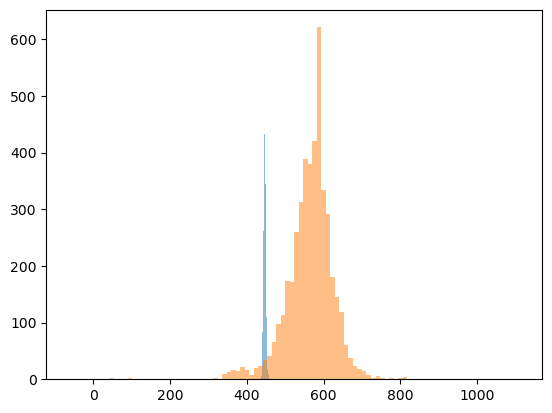

In [ ]:
import matplotlib.pyplot as plt
plt.hist(predictions[:, 2].cpu().detach().numpy(), bins=100, alpha=0.5, label='Predictions')
plt.hist(data.iloc[:, 2], bins=100, alpha=0.5, label='Data')